<a href="https://colab.research.google.com/github/ktw-98/Portfolio/blob/main/Optimal_Trajectory_Planning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# I. Optimal Trajectory Planning


In [ ]:
#!pip install ECOS
!pip install ecos scs
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as sla

import jax
import jax.numpy as jnp
from tqdm import tqdm
import cvxpy as cp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 5.4 MB/s eta 0:00:00


시뮬레이션 파라미터

팰콘 9 기준 상공 5km 부근에서
- 속도 1,100km/h = 약 300m/s
- 터치다운까지 약 30s

In [ ]:
N = 300
T = 30
ts = np.linspace(0, T, N+1)
h = T / N

gamma = 0.05
g = 9.8

n = 6   # state dim
m = 3   # control dim

x0 = np.array([1000, 500, 5000, 50, -10, -300])

##1. Least-sqaure 방식

1.1 최적화 식 파라미터 구현

- 상태 공간 방정식

$$
  x_{t+1} = Ax_t + Bu_t + b
$$

- 가중치 $Q_t, Q_N, R, \rho$ 설정



In [ ]:
I3 = np.eye(3)

A = np.block([
    [I3, (1 - gamma*h/2)*h*I3],
    [np.zeros((3,3)), (1 - gamma*h)*I3]
])

B = np.block([
    [(h**2)/2 * I3],
    [h * I3]
])

b = np.array([0, 0, -0.5*g*h**2, 0, 0, -g*h])

# Q_list = []
# for t in range(N):
#     alpha = np.exp(-(N - t)/18)       # 후반으로 갈 수록 커짐
#     Q_list.append(alpha * np.diag([1, 1, 0, 10, 10, 0]))
# Q_N = np.diag([10, 10, 100, 100, 100, 1000])

# R = np.eye(3)

Q = []
R = []
Q_tilde = []
R_tilde = []
for t in range(N):
  Qt = np.exp(-(N-t)/15)*np.diag([10,10,  0,100,100,   0])
  Rt = np.eye(m)
  Q.append(Qt)
  R.append(Rt)
Q.append(np.diag([ 10,10,100,100,100,1000]))


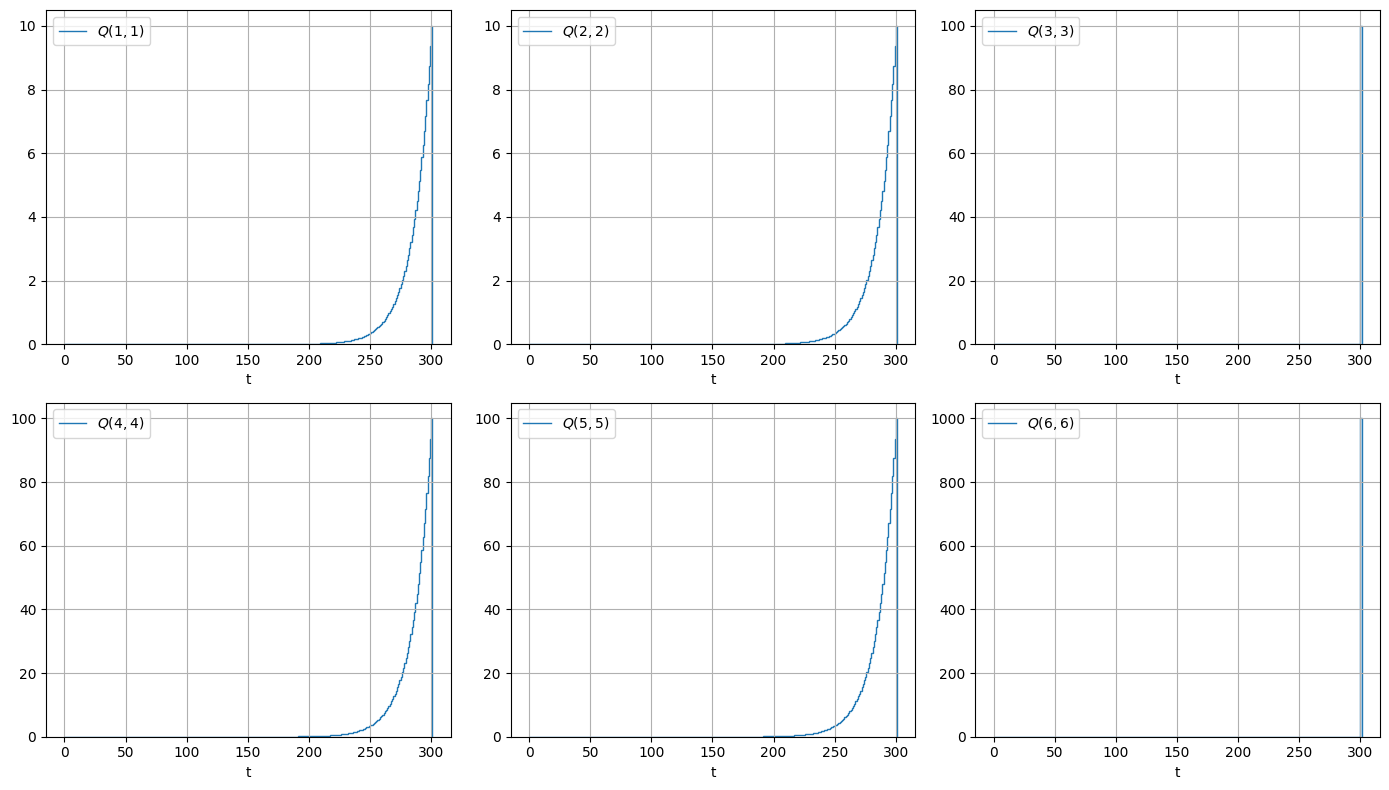

In [ ]:
labels_x = [r'$p_e$', r'$p_n$', r'$p_u$', r'$v_e$', r'$v_n$', r'$v_u$']

plt.figure(figsize=(14,8), dpi=100)
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.stairs([Q[t][i,i] for t in range(N+1)],
               label=rf'$Q({i+1},{i+1})$')
    plt.grid(); plt.legend(); plt.xlabel('t')
plt.tight_layout()
plt.show()


1.2 $y$ 스태킹
$$
  y = [x_1, ... , x_N, u_0, ... , u_{N-1}]^T x \in \mathbb{R}^{9N}
$$

In [ ]:
dim_x = 6
dim_u = 3
dim_y = (dim_x + dim_u) * N   # 9N = 1800

def idx_x(t):
    # x_t for t=1..N  (x0는 변수에 없음)
    s = (t-1) * dim_x
    return slice(s, s + dim_x)

def idx_u(t):
    # u_t for t=0..N-1
    base = dim_x * N
    s = base + t * dim_u
    return slice(s, s + dim_u)


def unpack_y(y):
  x = np.zeros((dim_x, N+1))
  u = np.zeros((dim_u, N))
  x[:, 0] = x0
  for t in range(1, N+1):
    x[:, t] = y[idx_x(t)]
  for t in range(N):
    u[:, t] = y[idx_u(t)]
  return x, u

def pack_y(x, u):
    y = np.zeros(dim_y)
    # x1..xN
    for t in range(1, N+1):
        y[idx_x(t)] = x[:, t]
    # u0..u_{N-1}
    for t in range(N):
        y[idx_u(t)] = u[:, t]
    return y


In [ ]:
print("N =", N)
print("dim_x, dim_u =", dim_x, dim_u)
print("dim_y =", dim_y)

print("idx_x(N) =", idx_x(N))
print("idx_u(N-1) =", idx_u(N-1))


N = 300
dim_x, dim_u = 6 3
dim_y = 2700
idx_x(N) = slice(1794, 1800, None)
idx_u(N-1) = slice(2697, 2700, None)


1.3 LS 구성 (scipy.sparse 사용)

$$
\begin{aligned}
\min_{\{x_t,u_t\}} \quad
& \sum_{t=1}^{N-1} \left\| Q^{1/2} x_t \right\|_2^2
+ \left\| Q_N^{1/2} (x_N - x_{\text{des}}) \right\|_2^2 \\
&\quad + \sum_{t=0}^{N-1} \left\| R^{1/2} u_t \right\|_2^2
+ \rho \sum_{t=0}^{N-1} \left\| x_{t+1} - A x_t - B u_t - b \right\|_2^2
\end{aligned}
$$

In [ ]:
def sqrt_diag_sparse(M):
    """
    M: np.ndarray (dense) or scipy sparse diagonal
    returns: csr sparse diagonal of sqrt(diag(M))
    """
    # scipy sparse면 대각만 뽑기
    if sp.issparse(M):
        d = M.diagonal()
    else:
        d = np.diag(M).copy()
    d = np.maximum(d, 0.0)
    return sp.diags(np.sqrt(d), format="csr")


def build_Gx_cx_sparse(x_des=None):
    if x_des is None:
        x_des = np.zeros(dim_x)

    blocks = []

    # running terms for x1..x_{N-1}
    # NOTE: x_t in y exists for t=1..N
    # so running uses t=1..N-1
    for t in range(1, N):
        W = sqrt_diag_sparse(Q[t])   # <-- Q[t] 사용
        row = sp.lil_matrix((dim_x, dim_y))
        row[:, idx_x(t)] = W
        blocks.append(row.tocsr())

    # terminal term xN - x_des
    WN = sqrt_diag_sparse(Q[N])      # <-- Q[N]이 terminal Q
    row = sp.lil_matrix((dim_x, dim_y))
    row[:, idx_x(N)] = WN
    blocks.append(row.tocsr())

    Gx = sp.vstack(blocks, format="csr")

    cx = np.zeros(Gx.shape[0], dtype=float)
    cx[-dim_x:] = (WN @ x_des)       # last block only

    return Gx, cx


def build_Gu_cu_sparse():
    blocks = []

    for t in range(N):
        WR = sqrt_diag_sparse(R[t])  # <-- 시간가변 R[t]
        row = sp.lil_matrix((dim_u, dim_y))
        row[:, idx_u(t)] = WR
        blocks.append(row.tocsr())

    Gu = sp.vstack(blocks, format="csr")
    cu = np.zeros(Gu.shape[0], dtype=float)
    return Gu, cu


def build_D_d_sparse():
    # 동역학은 Q/R랑 무관하므로 그대로 두면 됨
    D = sp.lil_matrix((dim_x * N, dim_y))
    d = np.zeros(dim_x * N, dtype=float)

    A_sp = sp.csr_matrix(A)
    B_sp = sp.csr_matrix(B)
    I6   = sp.eye(dim_x, format="csr")

    for t in range(N):
        rows = slice(t*dim_x, (t+1)*dim_x)

        # + x_{t+1}
        D[rows, idx_x(t+1)] = I6

        # -A x_t
        if t >= 1:
            D[rows, idx_x(t)] = D[rows, idx_x(t)] - A_sp
        else:
            d[rows] += A @ x0

        # -B u_t
        D[rows, idx_u(t)] = D[rows, idx_u(t)] - B_sp

        # -b
        d[rows] += b

    return D.tocsr(), d

1.4 LS 풀기 (cp.ECOS 사용)

\
\begin{aligned}
\min_{y}\quad & \|G_x y - c_x\|_2^2 + \|G_u y - c_u\|_2^2 \\
\text{s.t.}\quad & Dy = d
\end{aligned}


In [ ]:

x_des = np.zeros(dim_x)

Gx, cx = build_Gx_cx_sparse(x_des)
Gu, cu = build_Gu_cu_sparse()
D, d_vec = build_D_d_sparse()

y = cp.Variable(dim_y)
objective = cp.sum_squares(Gx @ y - cx) + cp.sum_squares(Gu @ y - cu)

xN = y[idx_x(N)]    #(6,)

constraints =[
    D @ y == d_vec,
    cp.norm(xN[0:2], 2) <= 30,
    xN[2] == 0,
    xN[3:6] == np.zeros(3)
]

prob = cp.Problem(cp.Minimize(objective), constraints)
prob.solve(solver=cp.ECOS, verbose=True)

(CVXPY) Mar 08 12:07:14 AM: Your problem has 2700 variables, 1805 constraints, and 0 parameters.
(CVXPY) Mar 08 12:07:14 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 08 12:07:15 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 08 12:07:15 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 08 12:07:15 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 08 12:07:15 AM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 08 12:07:15 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 08 12:07:15 AM: Applying reduction Dcp2Cone
(CVXPY) Mar 08 12:07:15 AM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 08 12:07:15 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 08 12:07:15 AM: Applying reduction ECOS
(CVXPY) Mar 08 12:07:15 AM: Finished problem compilation (too

                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
(CVXPY) Mar 08 12:07:15 AM: Problem status: optimal_inaccurate
(CVXPY) Mar 08 12:07:15 AM: Optimal value: 9.439e+04
(CVXPY) Mar 08 12:07:15 AM: Compilation took 8.445e-02 seconds
(CVXPY) Mar 08 12:07:15 AM: Solver (including time spent in interface) took 5.365e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


np.float64(94390.27843935894)

status: optimal_inaccurate | optimal value: 94390.27843935894
Hard-LS terminal position: [ 2.82465470e-04 -3.07829045e-04 -1.55312148e-11]
Hard-LS terminal velocity: [4.20305092e-14 9.19730507e-15 1.08744090e-09]
Hard-LS min p_u: -1.5531214813049673e-11
||dynamics residual||: 1.9798731997719582e-07


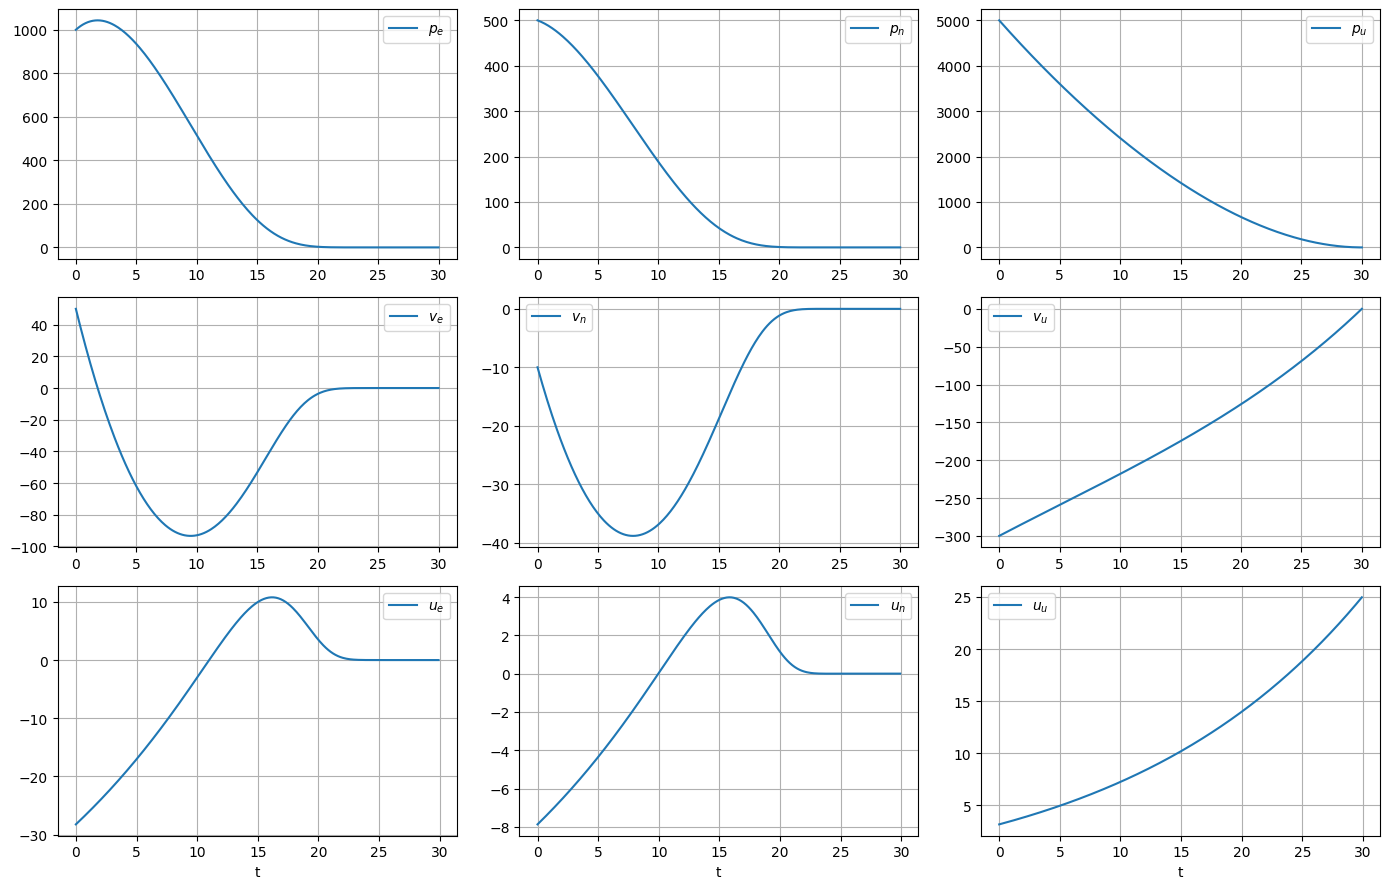

In [ ]:
print("status:", prob.status, "| optimal value:", prob.value)
y_ls = y.value
X_ls, U_ls = unpack_y(y_ls)

print("Hard-LS terminal position:", X_ls[:3, -1])
print("Hard-LS terminal velocity:", X_ls[3:, -1])
print("Hard-LS min p_u:", np.min(X_ls[2,1:]))

# dynamics residual check
dyn_res = D @ y_ls - d_vec
print("||dynamics residual||:", np.linalg.norm(dyn_res))


# plot
labels = [r'$p_e$',r'$p_n$',r'$p_u$',r'$v_e$',r'$v_n$',r'$v_u$',
          r'$u_e$',r'$u_n$',r'$u_u$']

plt.figure(figsize=(14,9), dpi=100)
for i in range(6):
    plt.subplot(3,3,i+1)
    plt.plot(ts, X_ls[i], label=labels[i])
    plt.grid(); plt.legend()
for i in range(3):
    plt.subplot(3,3,i+7)
    plt.plot(ts[:-1], U_ls[i], label=labels[i+6])
    plt.grid(); plt.legend(); plt.xlabel('t')
plt.tight_layout()
plt.show()

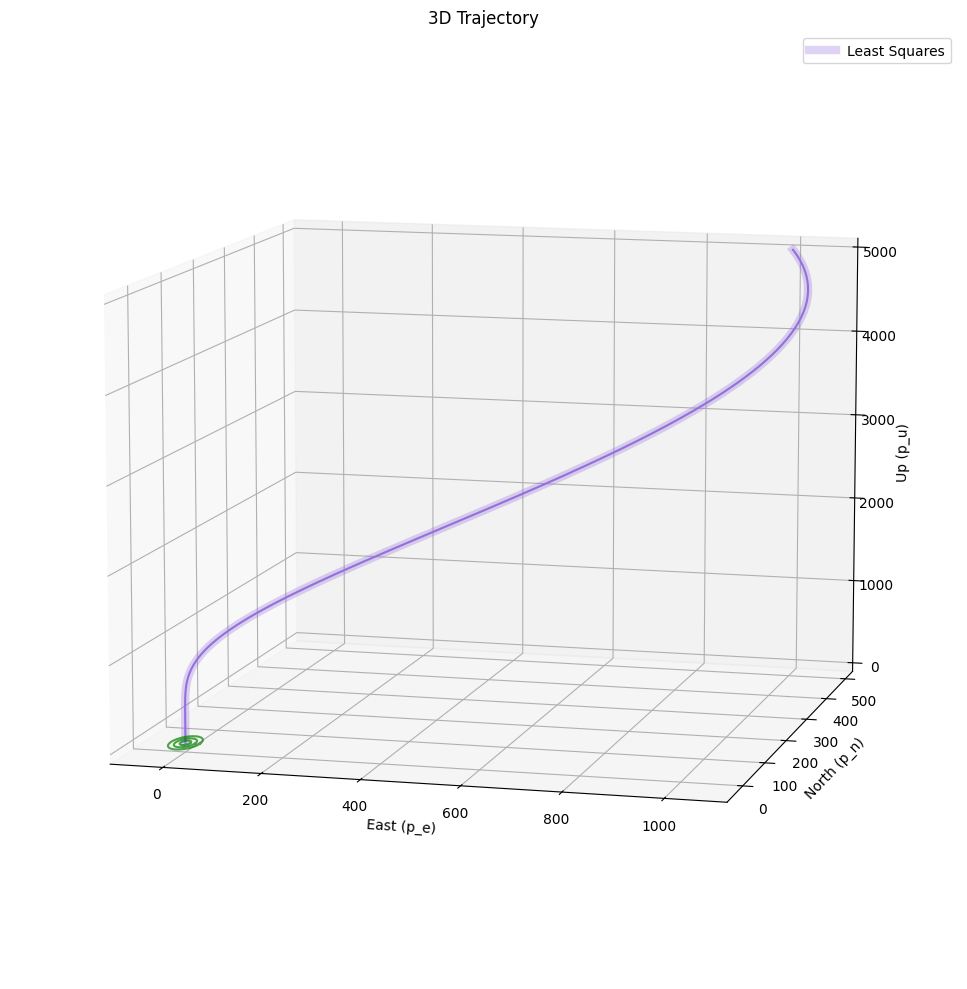

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=10, azim=-75, roll=0)

# ----- LS Trajectory -----
ax.plot(X_ls[0, :], X_ls[1, :], X_ls[2, :],
        color="mediumpurple", linewidth=6, alpha=0.3,
        label="Least Squares")
ax.plot(X_ls[0, :], X_ls[1, :], X_ls[2, :],
        color="mediumpurple", linewidth=1.5)

# ----- Landing pad (circles) -----
theta = np.linspace(0, 2*np.pi, 200)
radii = [10, 20, 30]

for r in radii:
    pe_circle = x_des[0] + r * np.cos(theta)
    pn_circle = x_des[1] + r * np.sin(theta)
    pu_circle = np.zeros_like(theta) + x_des[2]
    ax.plot(pe_circle, pn_circle, pu_circle, "g", alpha=0.7)

# ----- Labels & view -----
ax.set_xlabel("East (p_e)")
ax.set_ylabel("North (p_n)")
ax.set_zlabel("Up (p_u)")
ax.set_title("3D Trajectory")
ax.legend()

plt.tight_layout()
plt.show()


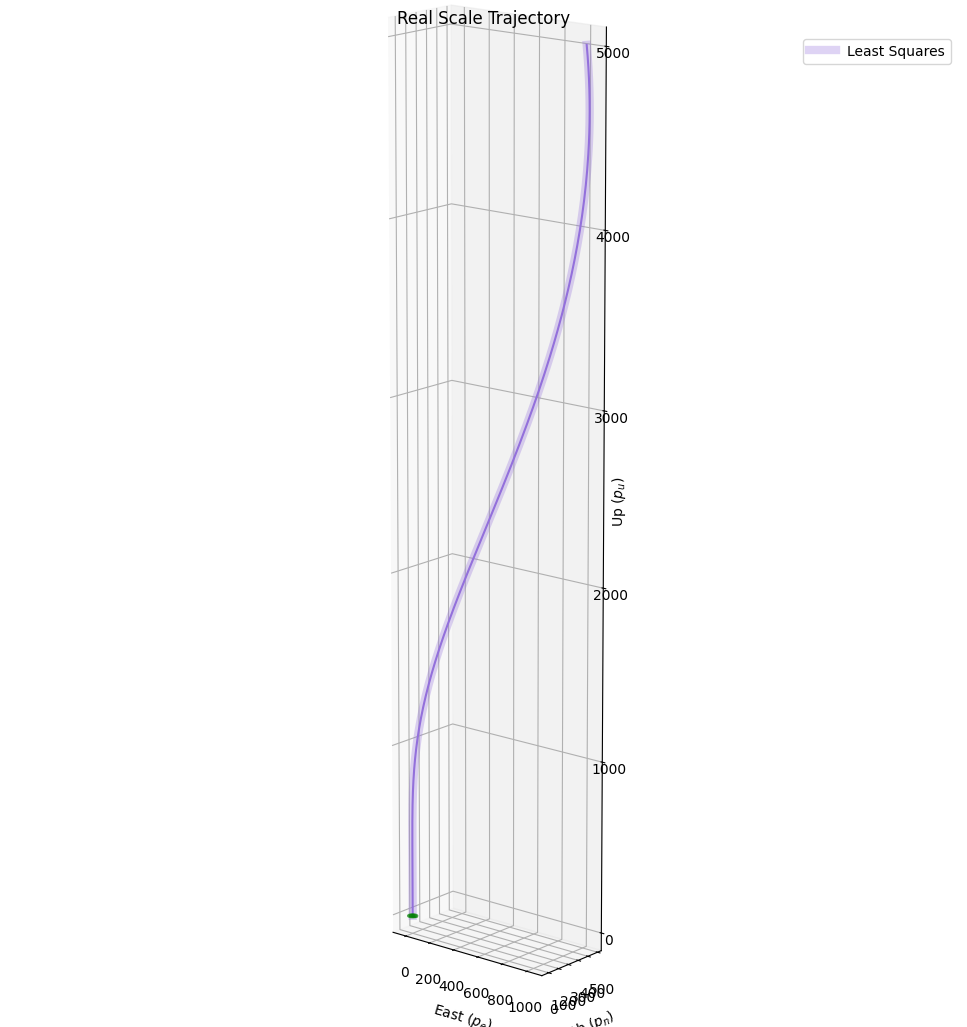

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=15, azim=-50, roll=0)

# =========================
# LS Trajectory
# =========================
ax.plot(X_ls[0,:], X_ls[1,:], X_ls[2,:],
        color="mediumpurple", linewidth=6, alpha=0.3,
        label="Least Squares")
ax.plot(X_ls[0,:], X_ls[1,:], X_ls[2,:],
        color="mediumpurple", linewidth=1.5)


# =========================
# Landing pad (circles)
# =========================
theta = np.linspace(0, 2*np.pi, 200)
radii = [10, 20, 30]

for r in radii:
    pe_circle = x_des[0] + r*np.cos(theta)
    pn_circle = x_des[1] + r*np.sin(theta)
    pu_circle = np.zeros_like(theta) + x_des[2]
    ax.plot(pe_circle, pn_circle, pu_circle,
            "g", alpha=0.7)


ax.set_xlabel("East $(p_e)$")
ax.set_ylabel("North $(p_n)$")
ax.set_zlabel("Up $(p_u)$")
ax.set_title("Real Scale Trajectory")
ax.legend()

ax.set_box_aspect((
    np.ptp(X_ls[0,:]),
    np.ptp(X_ls[1,:]),
    np.ptp(X_ls[2,:])
))

plt.tight_layout()
plt.show()


## 2. PGD (Projected Gradient Descent)

2.1 제약 projection
- 제어 입력 제약 :
$
  u_{min} ≤ u_t ≤u_{max}
$

In [ ]:
# ===== control bounds (hard) =====
u_min = np.array([-10.0, -10.0, 0.0], dtype=float)
u_max = np.array([ 10.0,  10.0, 20.0], dtype=float)

2.2 동역학 제약
- x는 equality하게 hard로
- u는 equality로는 어렵고 가중치 크게

In [ ]:
def rollout(U):
    # U: (3, N)
    X = np.zeros((dim_x, N+1), dtype=float)
    X[:, 0] = x0
    for t in range(N):
        X[:, t+1] = A @ X[:, t] + B @ U[:, t] + b
    return X

2.3 objective
- PGD에서 equality projection은 어려워서 가중치로 잡아서 하드로

In [ ]:
# ===== weights for soft/hard penalties =====
RADIUS = 30.0      # 30m 안에(소프트) 들어오게
w_rad  = 1e4       # 원 밖(>RADIUS) 위반 페널티
w_xy   = 1e3       # 원 안에서도 (pe,pn)->(0,0)로 더 끌어당기는 페널티
w_pu   = 1e6       # 터미널 높이(p_u(N)=0) 사실상 하드
w_v    = 1e6       # 터미널 속도(v(N)=0) 사실상 하드

def cost(U):
    # hard clip on control
    Uc = np.clip(U, u_min[:, None], u_max[:, None])
    X = rollout(Uc)

    # running state cost (t=1..N-1; x0 제외, xN은 terminal로 따로)
    Jx = 0.0
    for t in range(1, N):
        xt = X[:, t]
        Jx += xt.T @ Q[t] @ xt

    # terminal state cost
    xN = X[:, N]
    JN = xN.T @ Q[N] @ xN

    # control cost (time-varying R[t])
    Ju = 0.0
    for t in range(N):
        ut = Uc[:, t]
        Ju += ut.T @ R[t] @ ut

    # terminal horizontal radius (soft hinge) + inside-circle pull to origin
    pe, pn = xN[0], xN[1]
    rad = np.sqrt(pe*pe + pn*pn)
    Jrad = w_rad * max(0.0, rad - RADIUS)**2   # RADIUS 밖이면 벌점
    Jxy  = w_xy  * (pe*pe + pn*pn)             # 원 안이어도 0으로 더 당김

    # (almost) hard: terminal altitude and velocity
    pu = xN[2]
    v  = xN[3:6]
    Jhard = w_pu * (pu - 0.0)**2 + w_v * (v @ v)

    return Jx + JN + Ju + Jrad + Jxy + Jhard

2.4 gradient 계산 (JAX 사용)

In [ ]:
import jax
import jax.numpy as jnp

A_j  = jnp.array(A, dtype=jnp.float64)
B_j  = jnp.array(B, dtype=jnp.float64)
b_j  = jnp.array(b, dtype=jnp.float64)
x0_j = jnp.array(x0, dtype=jnp.float64)

Q_j = jnp.stack([jnp.array(Q[t], dtype=jnp.float64) for t in range(N+1)], axis=0)  # (N+1,6,6)
R_j = jnp.stack([jnp.array(R[t], dtype=jnp.float64) for t in range(N)], axis=0)    # (N,3,3)

w_rad_j = 1e4
w_xy_j  = 1e3   # NEW
w_pu_j  = 1e6
w_v_j   = 1e6

@jax.jit
def rollout_j(U):
    def step(x, u):
        x_next = A_j @ x + B_j @ u + b_j
        return x_next, x_next
    _, X_hist = jax.lax.scan(step, x0_j, U.T)     # (N,6)
    X = jnp.vstack([x0_j[None,:], X_hist])        # (N+1,6)
    return X.T                                     # (6,N+1)

@jax.jit
def obj(U_flat):
    U = U_flat.reshape(3, N)
    X = rollout_j(U)

    def run_cost(t, acc):
        xt = X[:, t]
        return acc + xt @ Q_j[t] @ xt
    Jx = jax.lax.fori_loop(1, N, run_cost, 0.0)

    xN = X[:, N]
    JN = xN @ Q_j[N] @ xN

    Ju = jnp.sum(jnp.einsum('it,tij,jt->t', U, R_j, U))

    pe, pn = xN[0], xN[1]
    rad = jnp.sqrt(pe*pe + pn*pn)
    Jrad = w_rad_j * jnp.maximum(0.0, rad - 30.0)**2
    Jxy  = w_xy_j  * (pe*pe + pn*pn)   # NEW

    pu = xN[2]
    v  = xN[3:6]
    Jhard = w_pu_j * (pu - 0.0)**2 + w_v_j * (v @ v)

    return Jx + JN + Ju + Jrad + Jxy + Jhard

grad_obj = jax.jit(jax.grad(obj))

/tmp/ipykernel_543/3537194873.py:4: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  A_j  = jnp.array(A, dtype=jnp.float64)
/tmp/ipykernel_543/3537194873.py:5: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  B_j  = jnp.array(B, dtype=jnp.float64)
/tmp/ipykernel_543/3537194873.py:6: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes

2.5 PGD loop

In [ ]:
# def solve_adam(U0, lr=1e-4, iters=200_000, eps=1e-8,
#                beta1=0.9, beta2=0.999, adam_eps=1e-8,
#                log_every=5000):
#     # init + hard bounds
#     U = np.clip(U0, u_min[:, None], u_max[:, None])
#     U_flat = U.reshape(-1)

#     m = np.zeros_like(U_flat)
#     v = np.zeros_like(U_flat)

#     hist_f = []
#     hist_g = []
#     for k in tqdm(range(iters), desc="Adam-PGD (u-only)"):
#         g = np.array(grad_obj(jnp.array(U_flat)))
#         ng = np.linalg.norm(g)

#         # Adam moments
#         m = beta1 * m + (1 - beta1) * g
#         v = beta2 * v + (1 - beta2) * (g * g)

#         # bias correction
#         mhat = m / (1 - beta1 ** (k + 1))
#         vhat = v / (1 - beta2 ** (k + 1))

#         # Adam update
#         U_flat = U_flat - lr * mhat / (np.sqrt(vhat) + adam_eps)

#         # projection (hard bounds)
#         U = U_flat.reshape(3, N)
#         U = np.clip(U, u_min[:, None], u_max[:, None])
#         U_flat = U.reshape(-1)

#         # stop condition (optional)
#         if ng < eps:
#             print(f"Converged at iter {k} with ||grad||={ng:.3e}")
#             break

#         if k % log_every == 0:
#             fval = float(obj(jnp.array(U_flat)))
#             X = rollout(U)
#             xN = X[:, -1]
#             rad = np.linalg.norm(xN[0:2])
#             vnorm = np.linalg.norm(xN[3:6])
#             hist_f.append(fval)
#             hist_g.append(ng)
#             print(f"iter {k:6d} | f={fval:.3e} | ||g||={ng:.3e} | rad={rad:.2f} | pu={xN[2]:.2f} | vnorm={vnorm:.2f}")

#     U_sol = U_flat.reshape(3, N)
#     X_sol = rollout(U_sol)
#     return X_sol, U_sol, np.array(hist_f), np.array(hist_g)

# # 초기값: 중력 보상
# U_init = np.zeros((3, N))
# U_init[2, :] = g

# X_pgd, U_pgd, hist_f, hist_g = solve_adam(U_init, lr=1e-2, iters=100_000, eps=1e-6, log_every=5000)
# print("Adam-PGD terminal position:", X_pgd[:3, -1])
# print("Adam-PGD terminal velocity:", X_pgd[3:, -1])
# print("Adam-PGD terminal radius:", np.linalg.norm(X_pgd[0:2, -1]))
# print("Adam-PGD min p_u:", np.min(X_pgd[2, 1:]))

In [ ]:
import numpy as np
import jax.numpy as jnp
from tqdm import tqdm

def solve_adam(U0, lr=1e-4, iters=200_000, eps=1e-8,
               beta1=0.9, beta2=0.99, adam_eps=1e-8,
               log_every=5000,
               lr_decay=1e-4,          # lr_k = lr / (1 + lr_decay*k)
               clip_norm=1e5):         # gradient clipping norm
    # init + hard bounds
    U = np.clip(U0, u_min[:, None], u_max[:, None])
    U_flat = U.reshape(-1)

    m = np.zeros_like(U_flat)
    v = np.zeros_like(U_flat)

    # save ALL iterations
    hist_f = []
    hist_g = []

    # track best (smallest grad norm)
    best_g = np.inf
    best_k = -1
    best_U_flat = U_flat.copy()

    for k in tqdm(range(iters), desc="Adam-PGD (u-only)"):
        # grad at current point
        g = np.array(grad_obj(jnp.array(U_flat)))
        ng = float(np.linalg.norm(g))

        # ---- gradient clipping ----
        if clip_norm is not None and ng > clip_norm:
            g = g * (clip_norm / (ng + 1e-12))
            ng = clip_norm

        # record every iteration (at current point)
        fval_now = float(obj(jnp.array(U_flat)))
        hist_f.append(fval_now)
        hist_g.append(ng)

        # update best by smallest grad norm
        if ng < best_g:
            best_g = ng
            best_k = k
            best_U_flat = U_flat.copy()

        # ---- Adam moments ----
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g * g)

        # bias correction
        mhat = m / (1 - beta1 ** (k + 1))
        vhat = v / (1 - beta2 ** (k + 1))

        # ---- lr schedule (decay) ----
        lr_k = lr / (1.0 + lr_decay * k)

        # Adam update
        U_flat = U_flat - lr_k * mhat / (np.sqrt(vhat) + adam_eps)

        # projection (hard bounds)
        U = U_flat.reshape(3, N)
        U = np.clip(U, u_min[:, None], u_max[:, None])
        U_flat = U.reshape(-1)

        # stop condition (optional)
        if ng < eps:
            print(f"Converged at iter {k} with ||grad||={ng:.3e}")
            break

        if (k % log_every) == 0:
            X = rollout(U)
            xN = X[:, -1]
            rad = np.linalg.norm(xN[0:2])
            vnorm = np.linalg.norm(xN[3:6])
            print(f"iter {k:6d} | lr={lr_k:.2e} | f={fval_now:.3e} | ||g||={ng:.3e} | "
                  f"rad={rad:.2f} | pu={xN[2]:.2f} | vnorm={vnorm:.2f} | best_g={best_g:.3e} @ {best_k}")

    # return solution at smallest gradient norm (not the last iter)
    U_sol = best_U_flat.reshape(3, N)
    X_sol = rollout(U_sol)
    if best_k >= 0:
        print(f"[best] iter {best_k} | best ||g||={best_g:.3e} | f={hist_f[best_k]:.3e}")

    return X_sol, U_sol, np.array(hist_f), np.array(hist_g)


# =========================
# Usage
# =========================

# 초기값: 중력 보상
U_init = np.zeros((3, N))
U_init[2, :] = g

# 추천 기본값: lr 낮추고(1e-3) + decay + grad clip + beta2=0.99
X_pgd, U_pgd, hist_f, hist_g = solve_adam(
    U_init,
    lr=1e-3,
    iters=100_000,
    eps=1e-6,
    beta1=0.9,
    beta2=0.99,
    adam_eps=1e-8,
    log_every=5000,
    lr_decay=1e-4,
    clip_norm=1e5
)

print("Adam-PGD terminal position:", X_pgd[:3, -1])
print("Adam-PGD terminal velocity:", X_pgd[3:, -1])
print("Adam-PGD terminal radius:", np.linalg.norm(X_pgd[0:2, -1]))
print("Adam-PGD min p_u:", np.min(X_pgd[2, 1:]))

Adam-PGD (u-only):   0%|          | 59/100000 [00:01<40:27, 41.17it/s]  

iter      0 | lr=1.00e-03 | f=1.593e+11 | ||g||=1.000e+05 | rad=1808.60 | pu=345.13 | vnorm=67.66 | best_g=1.000e+05 @ 0


Adam-PGD (u-only):   5%|▌         | 5094/100000 [00:13<03:27, 458.45it/s]

iter   5000 | lr=6.67e-04 | f=7.957e+09 | ||g||=1.000e+05 | rad=576.47 | pu=1.65 | vnorm=67.55 | best_g=1.000e+05 @ 0


Adam-PGD (u-only):  10%|█         | 10077/100000 [00:24<02:43, 549.62it/s]

...

iter  90000 | lr=1.00e-04 | f=1.801e+05 | ||g||=7.325e+03 | rad=0.04 | pu=0.02 | vnorm=0.00 | best_g=6.462e+03 @ 85760


Adam-PGD (u-only):  95%|█████████▌| 95215/100000 [01:54<00:04, 1075.33it/s]

iter  95000 | lr=9.52e-05 | f=1.796e+05 | ||g||=2.054e+04 | rad=0.04 | pu=0.01 | vnorm=0.00 | best_g=6.425e+03 @ 93752


Adam-PGD (u-only): 100%|██████████| 100000/100000 [01:58<00:00, 843.82it/s]

[best] iter 98972 | best ||g||=6.365e+03 | f=1.793e+05
Adam-PGD terminal position: [3.87265928e-02 1.11913439e-06 1.91872620e-02]
Adam-PGD terminal velocity: [-1.15222149e-05  4.16383475e-06  1.73919613e-04]
Adam-PGD terminal radius: 0.03872659278965447
Adam-PGD min p_u: 0.01918726196440787


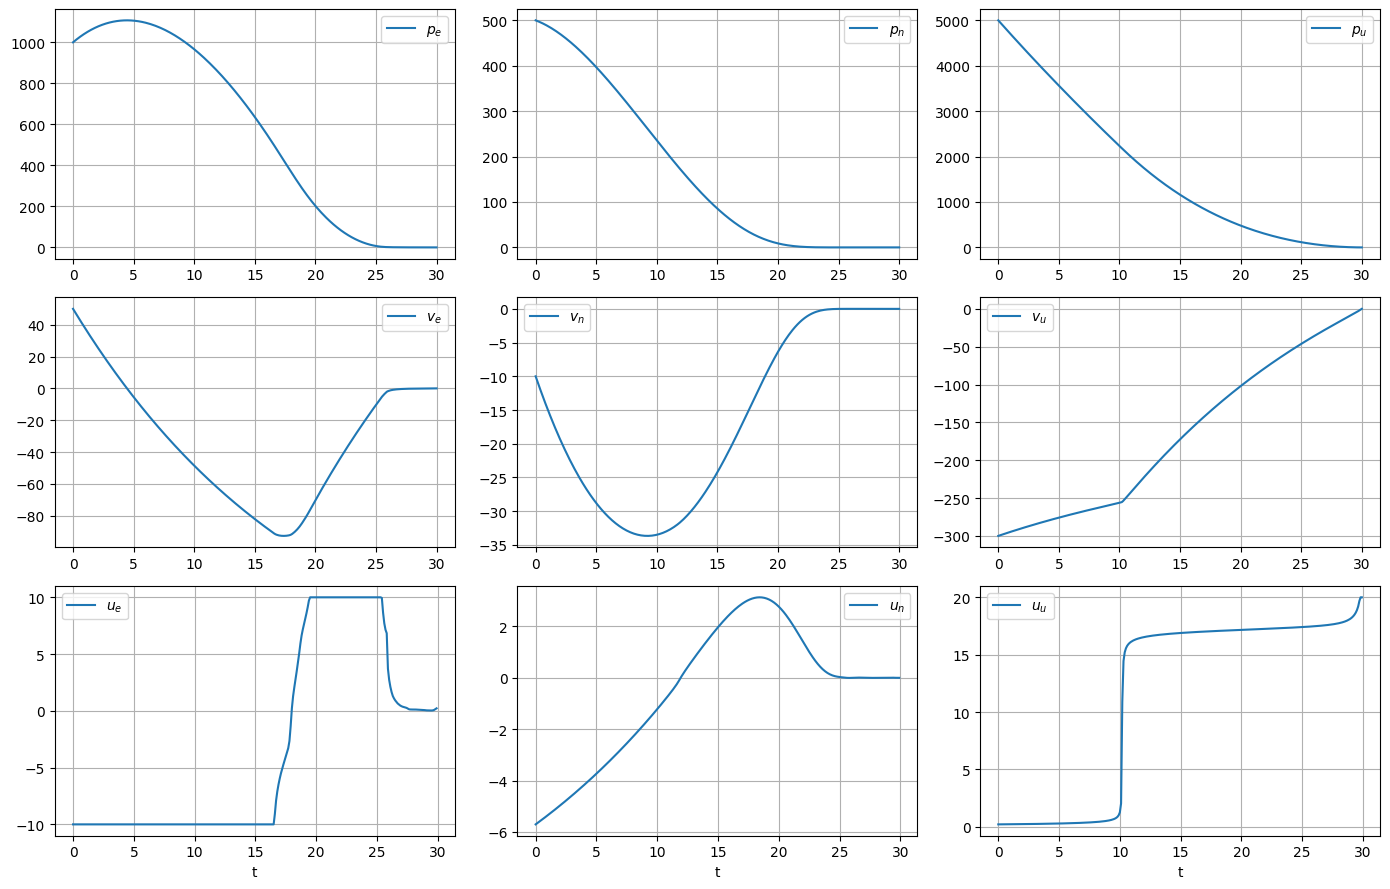

In [ ]:
labels = [r'$p_e$',r'$p_n$',r'$p_u$',r'$v_e$',r'$v_n$',r'$v_u$',
          r'$u_e$',r'$u_n$',r'$u_u$']

plt.figure(figsize=(14,9), dpi=100)
for i in range(6):
    plt.subplot(3,3,i+1)
    plt.plot(ts, X_pgd[i], label=labels[i])
    plt.grid(); plt.legend()
for i in range(3):
    plt.subplot(3,3,i+7)
    plt.plot(ts[:-1], U_pgd[i], label=labels[i+6])
    plt.grid(); plt.legend(); plt.xlabel('t')
plt.tight_layout()
plt.show()

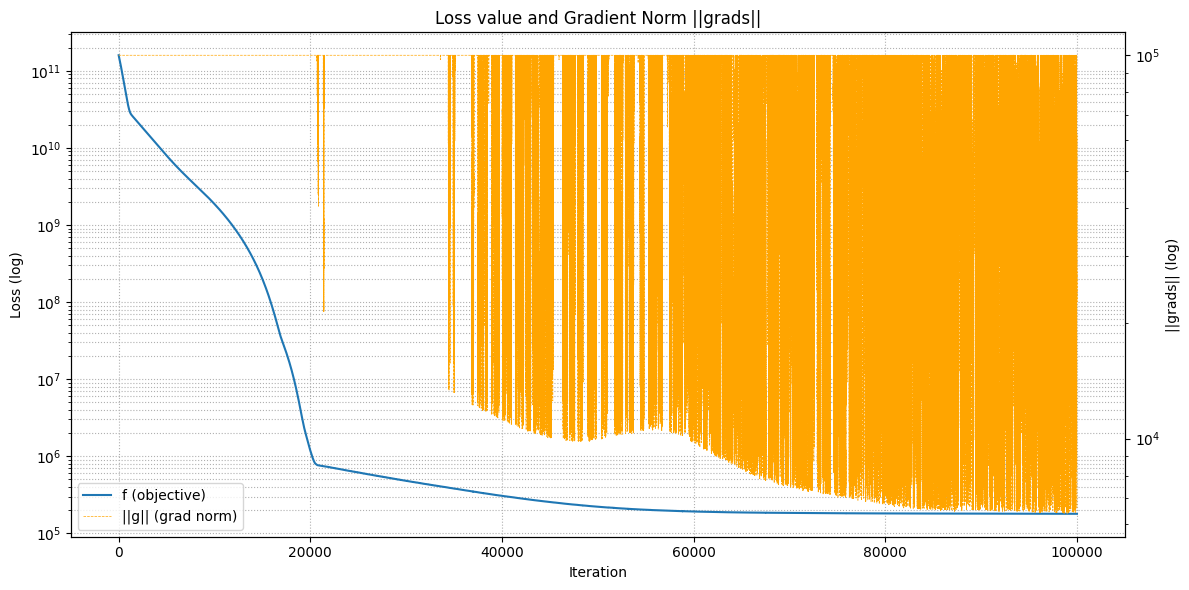

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

iters_axis = np.arange(len(hist_f))  # 실제 iteration 축

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(iters_axis, hist_f, label="f (objective)")
ax1.set_yscale("log")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss (log)")
ax1.grid(True, which="both", ls=":")

ax2 = ax1.twinx()
ax2.plot(iters_axis, hist_g,linestyle="--", linewidth=0.5, color = 'orange', label="||g|| (grad norm)")
ax2.set_yscale("log")
ax2.set_ylabel("||grads|| (log)")

ax1.set_title("Loss value and Gradient Norm ||grads||")

# (선택) 범례를 한 곳에 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.show()

In [ ]:
print("PGD terminal position: [p_e, p_n, p_u] =", X_pgd[:3, -1])
print("PGD terminal velocity: [v_e, v_n, v_u]", X_pgd[3:, -1])
print("gradient:", hist_g[-1])

print("Adam-PGD terminal position:", np.round(X_pgd[:3, -1], 6))
print("Adam-PGD terminal velocity:", np.round(X_pgd[3:, -1], 6))
print("Adam-PGD terminal radius:", round(float(np.linalg.norm(X_pgd[0:2, -1])), 6))
print("gradient:", np.round(hist_g[-1], 6))

PGD terminal position: [p_e, p_n, p_u] = [3.87265928e-02 1.11913439e-06 1.91872620e-02]
PGD terminal velocity: [v_e, v_n, v_u] [-1.15222149e-05  4.16383475e-06  1.73919613e-04]
gradient: 27222.6953125
Adam-PGD terminal position: [3.8727e-02 1.0000e-06 1.9187e-02]
Adam-PGD terminal velocity: [-1.20e-05  4.00e-06  1.74e-04]
Adam-PGD terminal radius: 0.038727
gradient: 27222.695312


2.4 시각화

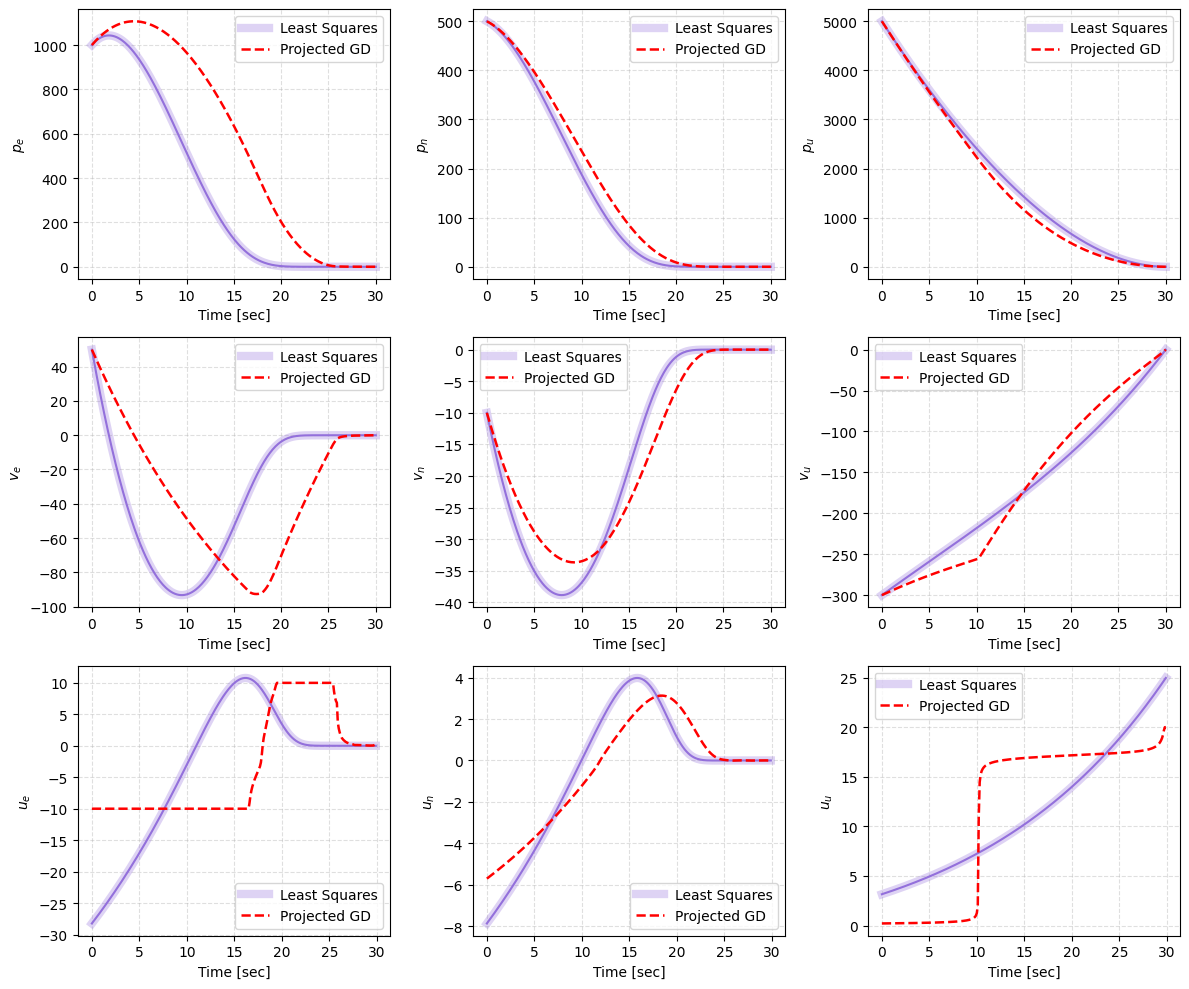

In [ ]:
import matplotlib.pyplot as plt

ts_x = ts
ts_u = ts[:-1]

pos_labels = [r"$p_e$", r"$p_n$", r"$p_u$"]
vel_labels = [r"$v_e$", r"$v_n$", r"$v_u$"]
u_labels   = [r"$u_e$", r"$u_n$", r"$u_u$"]

plt.figure(figsize=(12, 10))

# =========================
# 1) Position (X)
# =========================
for i in range(3):
    ax = plt.subplot(3, 3, i+1)
    ax.plot(ts_x, X_ls[i, :], color="mediumpurple", linewidth=6, alpha=0.3, label="Least Squares")
    ax.plot(ts_x, X_ls[i, :], color="mediumpurple", linewidth=1.5)
    ax.plot(ts_x, X_pgd[i, :], "r--", linewidth=1.8, label="Projected GD")

    ax.set_ylabel(pos_labels[i])
    ax.set_xlabel("Time [sec]")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

# =========================
# 2) Velocity (X)
# =========================
for i in range(3):
    ax = plt.subplot(3, 3, i+4)
    ax.plot(ts_x, X_ls[3+i, :], color="mediumpurple", linewidth=6, alpha=0.3, label="Least Squares")
    ax.plot(ts_x, X_ls[3+i, :], color="mediumpurple", linewidth=1.5)
    ax.plot(ts_x, X_pgd[3+i, :], "r--", linewidth=1.8, label="Projected GD")

    ax.set_ylabel(vel_labels[i])
    ax.set_xlabel("Time [sec]")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

# =========================
# 3) Control Inputs (U)
# =========================
for i in range(3):
    ax = plt.subplot(3, 3, i+7)
    ax.plot(ts_u, U_ls[i, :], color="mediumpurple", linewidth=6, alpha=0.3, label="Least Squares")
    ax.plot(ts_u, U_ls[i, :], color="mediumpurple", linewidth=1.5)
    ax.plot(ts_u, U_pgd[i, :], "r--", linewidth=1.8, label="Projected GD")

    ax.set_ylabel(u_labels[i])
    ax.set_xlabel("Time [sec]")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.show()


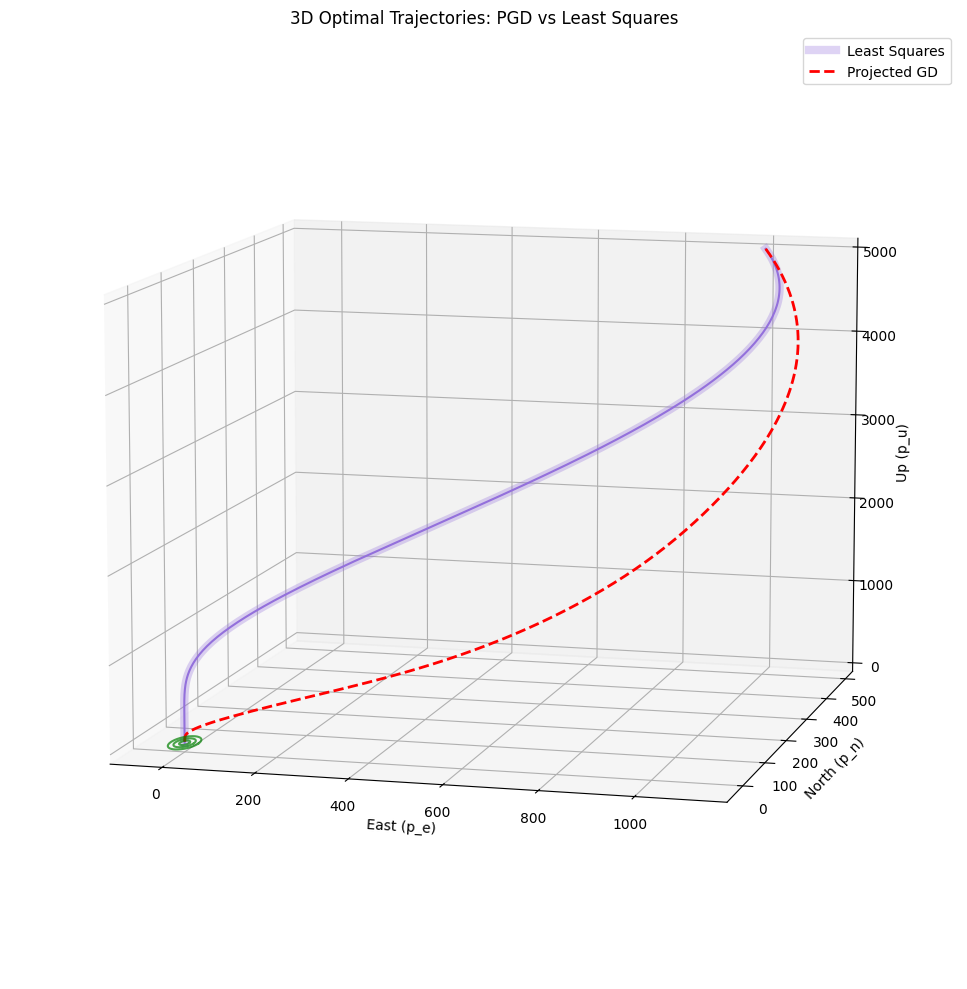

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=10, azim=-75, roll=0)

# ----- LS Trajectory -----
ax.plot(X_ls[0, :], X_ls[1, :], X_ls[2, :],
        color="mediumpurple", linewidth=6, alpha=0.3,
        label="Least Squares")
ax.plot(X_ls[0, :], X_ls[1, :], X_ls[2, :],
        color="mediumpurple", linewidth=1.5)

# ----- PGD Trajectory -----
ax.plot(X_pgd[0, :], X_pgd[1, :], X_pgd[2, :],
        "r--", linewidth=2.0, label="Projected GD")

# ----- Landing pad (circles) -----
theta = np.linspace(0, 2*np.pi, 200)
radii = [10, 20, 30]

for r in radii:
    pe_circle = x_des[0] + r * np.cos(theta)
    pn_circle = x_des[1] + r * np.sin(theta)
    pu_circle = np.zeros_like(theta) + x_des[2]
    ax.plot(pe_circle, pn_circle, pu_circle, "g", alpha=0.7)

# ----- Labels & view -----
ax.set_xlabel("East (p_e)")
ax.set_ylabel("North (p_n)")
ax.set_zlabel("Up (p_u)")
ax.set_title("3D Optimal Trajectories: PGD vs Least Squares")
ax.legend()

plt.tight_layout()
plt.show()


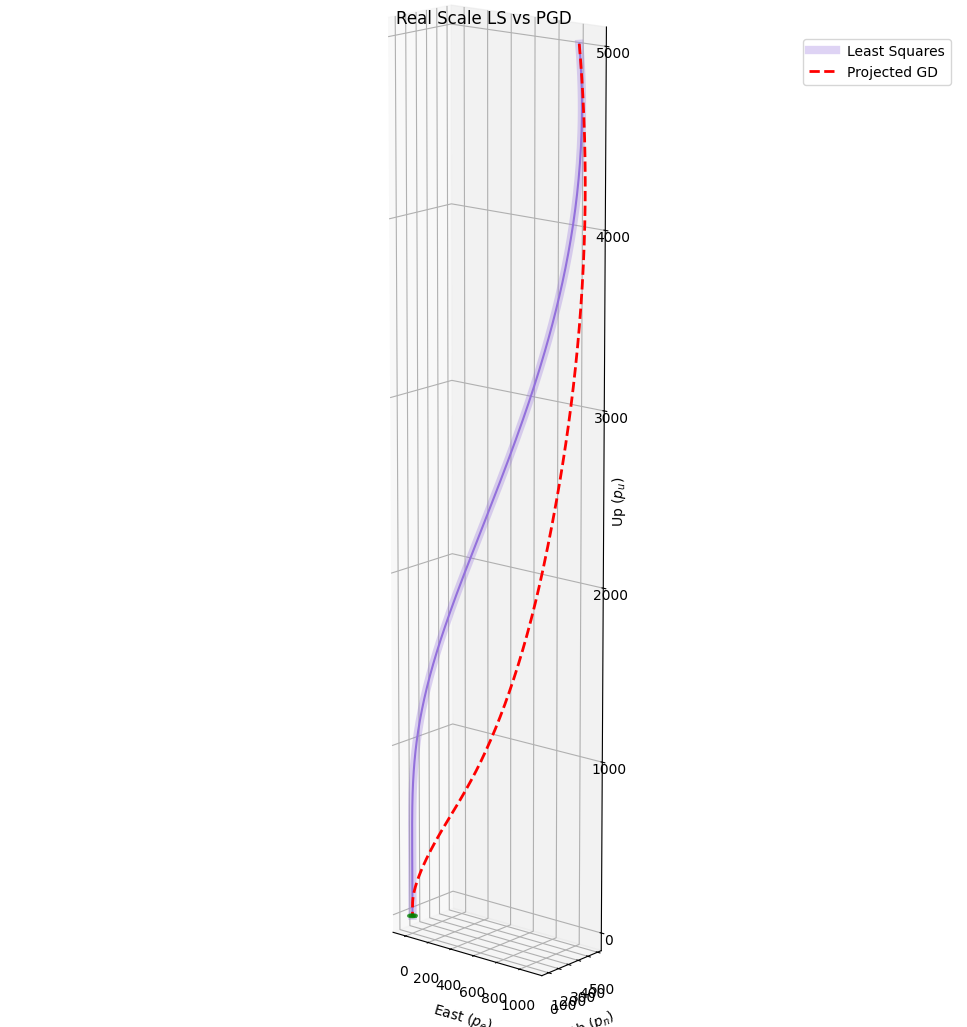

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=15, azim=-50, roll=0)

# =========================
# LS Trajectory
# =========================
ax.plot(X_ls[0,:], X_ls[1,:], X_ls[2,:],
        color="mediumpurple", linewidth=6, alpha=0.3,
        label="Least Squares")
ax.plot(X_ls[0,:], X_ls[1,:], X_ls[2,:],
        color="mediumpurple", linewidth=1.5)

# =========================
# PGD Trajectory
# =========================
ax.plot(X_pgd[0,:], X_pgd[1,:], X_pgd[2,:],
        "r--", linewidth=2.0, label="Projected GD")




# =========================
# Landing pad (circles)
# =========================
theta = np.linspace(0, 2*np.pi, 200)
radii = [10, 20, 30]

for r in radii:
    pe_circle = x_des[0] + r*np.cos(theta)
    pn_circle = x_des[1] + r*np.sin(theta)
    pu_circle = np.zeros_like(theta) + x_des[2]
    ax.plot(pe_circle, pn_circle, pu_circle,
            "g", alpha=0.7)


ax.set_xlabel("East $(p_e)$")
ax.set_ylabel("North $(p_n)$")
ax.set_zlabel("Up $(p_u)$")
ax.set_title("Real Scale LS vs PGD")
ax.legend()

ax.set_box_aspect((
    np.ptp(X_ls[0,:]),
    np.ptp(X_ls[1,:]),
    np.ptp(X_ls[2,:])
))

plt.tight_layout()
plt.show()


## 3. QP (Quadratic Programming) by CVXPY

3.1 구속 조건
- 동역학 : $x_{t+1} = Ax_t + Bu_t + b$

동역학을 hard constraint로 두려고 했는데, infeasible로 나와서 잔차로 바꿈
- 제어 입력 제약 :
$
  u_{min} ≤ u_t ≤u_{max}
$
- 고도 제한 :
$
  p_u(t) ≥0
$

- 종단 위치 제약 :
$
  p_{N(des)} = [0, 0,  0] \\
  p_{N(des)} <= [30, 30,  0]
$

- 종단 속도 제약 : $v_N = 0$

In [ ]:
u_min = np.array([-10, -10, 0])
u_max = np.array([ 10,  10, 20])

수식 넣자 ㅇㅇ
$$
  \min_{X, U} \sum_{t=0}^{N-1} \left( x_t^{T} Q_t x_t + u_t^{T} R u_t \right)
+ x_N^{T} Q_N x_N
$$

3.2 해 찾기 - 솔버 이용

In [ ]:
RADIUS = 30.0     # 30m 원 (소프트)
w_rad  = 1e4      # 원 밖 위반 페널티
w_xy   = 1e3      # 원 안에서도 원점으로 더 끌기(원하면 0으로)

w_du = 100.0      # 입력 스무딩(원하면 0으로)

# 목표 중심(원점 기준이면 0)
x_des = np.zeros(6)

# ===== decision variables =====
X = cp.Variable((6, N+1))
U = cp.Variable((3, N))

constraints = [X[:, 0] == x0]

# ===== hard dynamics =====
for t in range(N):
    constraints += [X[:, t+1] == A @ X[:, t] + B @ U[:, t] + b]

# ===== hard input box constraints =====
constraints += [U >= u_min[:, None], U <= u_max[:, None]]

# ===== hard ground constraint =====
constraints += [X[2, :] >= 0.0]        # p_u(t) >= 0

# ===== hard terminal constraints =====
constraints += [X[2, N] == 0.0]        # p_u(N)=0
constraints += [X[3:6, N] == 0.0]      # v(N)=0

# =========================
# cost
# =========================
cost = 0

# running state/input quadratic cost
for t in range(N):
    cost += cp.quad_form(X[:, t], Q[t])
    cost += cp.quad_form(U[:, t], R[t])

# terminal cost
cost += cp.quad_form(X[:, N], Q[N])

# input smoothing (optional)
for t in range(N-1):
    cost += w_du * cp.sum_squares(U[:, t+1] - U[:, t])

# soft circle penalty (terminal only)
peN = X[0, N] - x_des[0]
pnN = X[1, N] - x_des[1]
rad_violation = cp.pos(cp.norm(cp.hstack([peN, pnN]), 2) - RADIUS)
cost += w_rad * cp.square(rad_violation)

# (optional) pull-to-center even inside circle
cost += w_xy * (peN**2 + pnN**2)

problem = cp.Problem(cp.Minimize(cost), constraints)
problem.solve(solver=cp.CLARABEL, verbose=True)

X_opt = X.value
U_opt = U.value

(CVXPY) Mar 08 12:09:26 AM: Your problem has 2706 variables, 3911 constraints, and 0 parameters.
(CVXPY) Mar 08 12:09:26 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 08 12:09:26 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 08 12:09:26 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 08 12:09:26 AM: Your problem is compiled with the CPP canonicalization backend.


                                     CVXPY                                     
                                     v1.6.7                                    


(CVXPY) Mar 08 12:09:26 AM: Compiling problem (target solver=CLARABEL).
(CVXPY) Mar 08 12:09:26 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Mar 08 12:09:26 AM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Mar 08 12:09:26 AM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 08 12:09:26 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 08 12:09:27 AM: Applying reduction CLARABEL
(CVXPY) Mar 08 12:09:27 AM: Finished problem compilation (took 1.668e+00 seconds).
(CVXPY) Mar 08 12:09:27 AM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 6314
  constraints   = 7522
  nnz(P)        = 3006
  nnz(A)        = 16526
  cones (total) = 3
    :        Zero = 1,  numel = 5416
    : Nonnegative = 1,  numel = 2103
    : SecondOrder = 1,  numel = 3

settings:
  linear algebra: direct / qdldl, precision: 64 bit (1 thread)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  static reg : on, ϵ1

(CVXPY) Mar 08 12:09:27 AM: Problem status: optimal
(CVXPY) Mar 08 12:09:27 AM: Optimal value: 1.737e+05
(CVXPY) Mar 08 12:09:27 AM: Compilation took 1.668e+00 seconds
(CVXPY) Mar 08 12:09:27 AM: Solver (including time spent in interface) took 9.294e-02 seconds


  0  +2.9120e+07  +3.7163e+08  1.18e+01  5.64e-01  1.79e-01  1.00e+00  6.46e+06   ------   
  1  +6.2945e+06  +7.9241e+07  1.16e+01  2.01e-01  4.48e-02  3.73e+05  1.58e+06  8.00e-01  
  2  +6.5084e+05  +1.3287e+07  1.94e+01  6.08e-02  1.00e-02  4.89e+05  5.87e+05  8.23e-01  
  3  +2.4485e+05  +2.1985e+06  7.98e+00  1.29e-02  3.76e-03  5.31e+04  2.59e+05  6.48e-01  
  4  +2.4174e+05  +6.3522e+05  1.63e+00  2.71e-03  1.38e-03  1.84e+04  1.11e+05  6.77e-01  
  5  +2.3667e+05  +2.7488e+05  1.61e-01  3.61e-04  2.52e-04  2.07e+03  1.96e+04  8.38e-01  
  6  +1.9962e+05  +1.8353e+05  8.77e-02  5.41e-05  5.38e-05  3.05e+02  3.44e+03  8.45e-01  
  7  +1.8046e+05  +1.7154e+05  5.20e-02  7.63e-06  8.81e-06  4.51e+01  5.60e+02  8.84e-01  
  8  +1.7476e+05  +1.7277e+05  1.15e-02  6.51e-07  7.89e-07  4.64e+00  6.03e+01  9.27e-01  
  9  +1.7380e+05  +1.7356e+05  1.40e-03  3.25e-08  3.98e-08  3.24e-01  4.50e+00  9.57e-01  
 10  +1.7371e+05  +1.7369e+05  1.26e-04  1.67e-09  2.05e-09  2.20e-02  3.24e-01 

In [ ]:
print("status:", problem.status)
print("U_opt min/max per axis:", U_opt.min(axis=1), U_opt.max(axis=1))
print("terminal position:", X_opt[:3, -1])
print("terminal velocity:", X_opt[3:6, -1])
print("terminal radius:", np.linalg.norm(X_opt[0:2, -1] - x_des[0:2]))
print("min p_u:", np.min(X_opt[2, :]))

status: optimal
U_opt min/max per axis: [-10.          -5.58389491   2.12816824] [10.          3.01313569 19.99999996]
terminal position: [ 3.61887834e-02 -4.66533889e-04  1.49252599e-12]
terminal velocity: [ 3.56270837e-15 -3.12812535e-20  1.73785505e-15]
terminal radius: 0.03619179049308618
min p_u: 1.4925259921382899e-12


## 4. 시각화

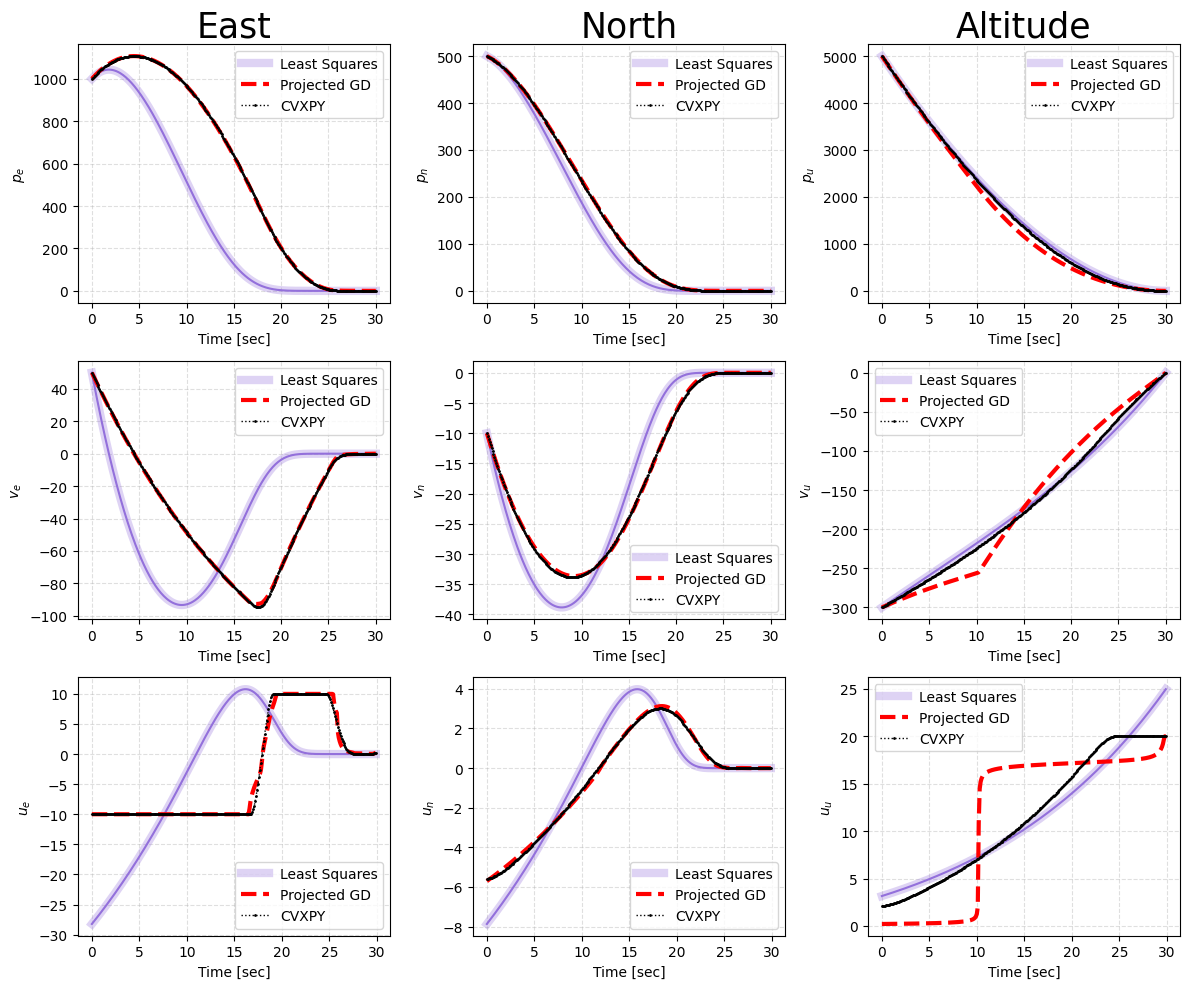

In [ ]:
import matplotlib.pyplot as plt

ts_x = ts
ts_u = ts[:-1]

pos_labels = [r"$p_e$", r"$p_n$", r"$p_u$"]
vel_labels = [r"$v_e$", r"$v_n$", r"$v_u$"]
u_labels   = [r"$u_e$", r"$u_n$", r"$u_u$"]
titles = ['East', 'North', 'Altitude']
plt.figure(figsize=(12, 10))

# =========================
# 1) Position (X)
# =========================
for i in range(3):
    ax = plt.subplot(3, 3, i+1)

    ax.plot(ts_x, X_ls[i, :],
            color="mediumpurple", linewidth=6, alpha=0.3, label="Least Squares")
    ax.plot(ts_x, X_ls[i, :],
            color="mediumpurple", linewidth=1.5)

    ax.plot(ts_x, X_pgd[i, :],
            "r--", linewidth=3, label="Projected GD")

    ax.plot(ts_x, X_opt[i, :],
            "k:", linewidth=1, marker="o", markersize=1,
            label="CVXPY")

    ax.set_ylabel(pos_labels[i])
    ax.set_xlabel("Time [sec]")
    ax.set_title(titles[i], fontsize=25)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

# =========================
# 2) Velocity (X)
# =========================
for i in range(3):
    ax = plt.subplot(3, 3, i+4)

    ax.plot(ts_x, X_ls[3+i, :],
            color="mediumpurple", linewidth=6, alpha=0.3, label="Least Squares")
    ax.plot(ts_x, X_ls[3+i, :],
            color="mediumpurple", linewidth=1.5)

    ax.plot(ts_x, X_pgd[3+i, :],
            "r--", linewidth=3, label="Projected GD")

    ax.plot(ts_x, X_opt[3+i, :],
            "k:", linewidth=1, marker="o", markersize=1,
            label="CVXPY")

    ax.set_ylabel(vel_labels[i])
    ax.set_xlabel("Time [sec]")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

# =========================
# 3) Control Inputs (U)
# =========================
for i in range(3):
    ax = plt.subplot(3, 3, i+7)

    ax.plot(ts_u, U_ls[i, :],
            color="mediumpurple", linewidth=6, alpha=0.3, label="Least Squares")
    ax.plot(ts_u, U_ls[i, :],
            color="mediumpurple", linewidth=1.5)

    ax.plot(ts_u, U_pgd[i, :],
            "r--", linewidth=3, label="Projected GD")

    ax.plot(ts_u, U_opt[i, :],
            "k:", linewidth=1, marker="o", markersize=1,
            label="CVXPY")

    ax.set_ylabel(u_labels[i])
    ax.set_xlabel("Time [sec]")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.show()


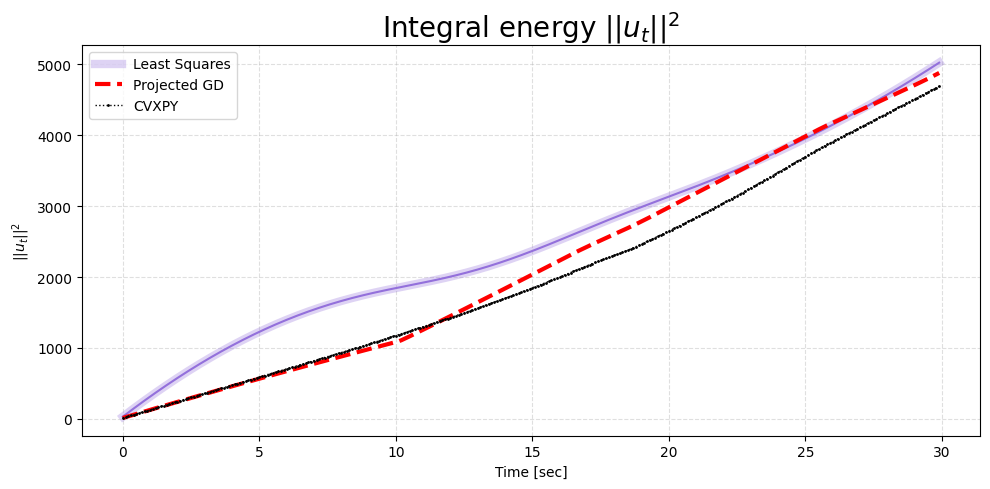

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ts_u = ts[:-1]  # (N,)

# per-step total = ||u(t)||_2
def total_per_step(U):
    return np.linalg.norm(U, axis=0)  # (N,)

tot_ls  = total_per_step(U_ls)
tot_pgd = total_per_step(U_pgd)
tot_qp  = total_per_step(U_opt)

# cumulative sum (원하면 *h 해서 적분처럼)
cum_ls  = np.cumsum(tot_ls)
cum_pgd = np.cumsum(tot_pgd)
cum_qp  = np.cumsum(tot_qp)

# ===== 스타일: 네 3x3 플롯과 동일 =====
plt.figure(figsize=(10, 5))

# LS: mediumpurple 두 번(굵은 투명 + 얇은 실선)
plt.plot(ts_u, cum_ls, color="mediumpurple", linewidth=6, alpha=0.3, label="Least Squares")
plt.plot(ts_u, cum_ls, color="mediumpurple", linewidth=1.5)

# PGD: 빨간 점선 굵게
plt.plot(ts_u, cum_pgd, "r--", linewidth=3, label="Projected GD")

# QP: 검은 점선 + 작은 동그라미 마커
plt.plot(ts_u, cum_qp, "k:", linewidth=1, marker="o", markersize=1, label="CVXPY")

plt.xlabel("Time [sec]")
plt.ylabel("$||u_t||^2$")
plt.title("Integral energy $||u_t||^2$", fontsize=20)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

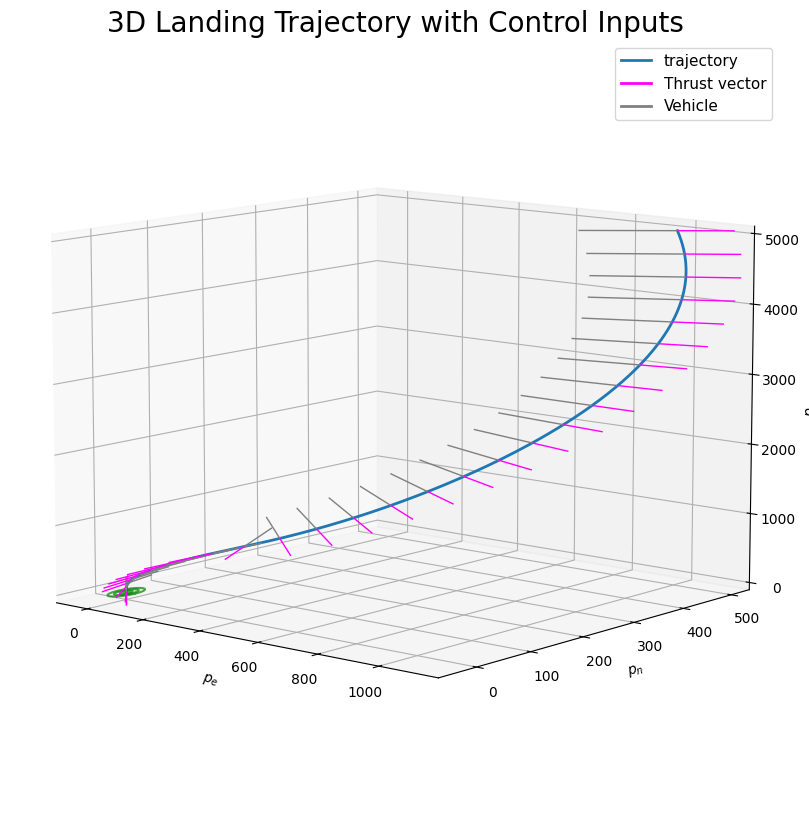

In [ ]:
def draw_3d_traj(x1, u1, x2=[], u2=[]):
    fig = plt.figure(figsize=(12,10), dpi=100)
    ax  = fig.add_subplot(projection='3d')
    ax.view_init(elev=10, azim=-50, roll=0)

    _ = 10
    N_ = x1.shape[1]-1

    # ---- Trajectories ----
    ax.plot(*x1[:3,:], linewidth=2, label='Vehicle trajectory (CVXPY)')
    if len(x2):
        ax.plot(*x2[:3,:], color='red', linestyle='--', linewidth=2, label='Vehicle trajectory (Projected GD)')

    # ---- Control inputs (quiver) ----
    for i in range(0, N_, 10):
        __ = np.linalg.norm(u1[:,i])/200
        __ = max(__, 1e-6)

        ax.quiver(x1[0,i], x1[1,i], x1[2,i],
                  -u1[0,i]*_, -u1[1,i]*_, -u1[2,i]*_,
                  color='magenta', linewidths=1, arrow_length_ratio=0)

        ax.quiver(x1[0,i], x1[1,i], x1[2,i],
                  u1[0,i]/__, u1[1,i]/__, u1[2,i]/__,
                  color='gray', linewidths=1, arrow_length_ratio=0)

        if len(x2):
            __2 = np.linalg.norm(u2[:,i])/200
            __2 = max(__2, 1e-6)

            ax.quiver(x2[0,i], x2[1,i], x2[2,i],
                      -u2[0,i]*_, -u2[1,i]*_, -u2[2,i]*_,
                      color='red', linewidths=1, arrow_length_ratio=0)

            ax.quiver(x2[0,i], x2[1,i], x2[2,i],
                      u2[0,i]/__2, u2[1,i]/__2, u2[2,i]/__2,
                      color='black', linewidths=1, arrow_length_ratio=0)

    # ---- Landing pad ----
    theta = np.linspace(0, 2*np.pi, 200)
    radii = [10, 20, 30]
    for r in radii:
        pe_circle = x_des[0] + r * np.cos(theta)
        pn_circle = x_des[1] + r * np.sin(theta)
        pu_circle = np.zeros_like(theta) + x_des[2]
        ax.plot(pe_circle, pn_circle, pu_circle, "g", alpha=0.7)

    # ---- Dummy artists for legend (quiver용) ----
    traj1_proxy = plt.Line2D([0],[0],  lw=2)
    thrust1_proxy = plt.Line2D([0],[0], color='magenta', lw=2)
    dir1_proxy = plt.Line2D([0],[0], color='gray', lw=2)

    handles = [traj1_proxy, thrust1_proxy, dir1_proxy]
    labels  = ['trajectory', 'Thrust vector', 'Vehicle']

    if len(x2):
        traj2_proxy = plt.Line2D([0],[0], color='red', lw=2, linestyle='--')
        thrust2_proxy = plt.Line2D([0],[0], color='red', lw=2)
        dir2_proxy = plt.Line2D([0],[0], color='black', lw=2)

        handles += [traj2_proxy, thrust2_proxy, dir2_proxy]
        labels  += ['Trajectory (Projected GD)',
                    'Thrust vector (Projected GD)',
                    'Thrust direction (Projected GD)']

    ax.legend(handles, labels, loc='upper right', fontsize=11)

    # ---- Labels ----
    ax.set_xlabel(r'$p_e$')
    ax.set_ylabel(r'$p_n$')
    ax.set_zlabel(r'$p_u$')
    ax.set_title('3D Landing Trajectory with Control Inputs', fontsize=20)

    plt.show()
draw_3d_traj(X_opt, U_opt)

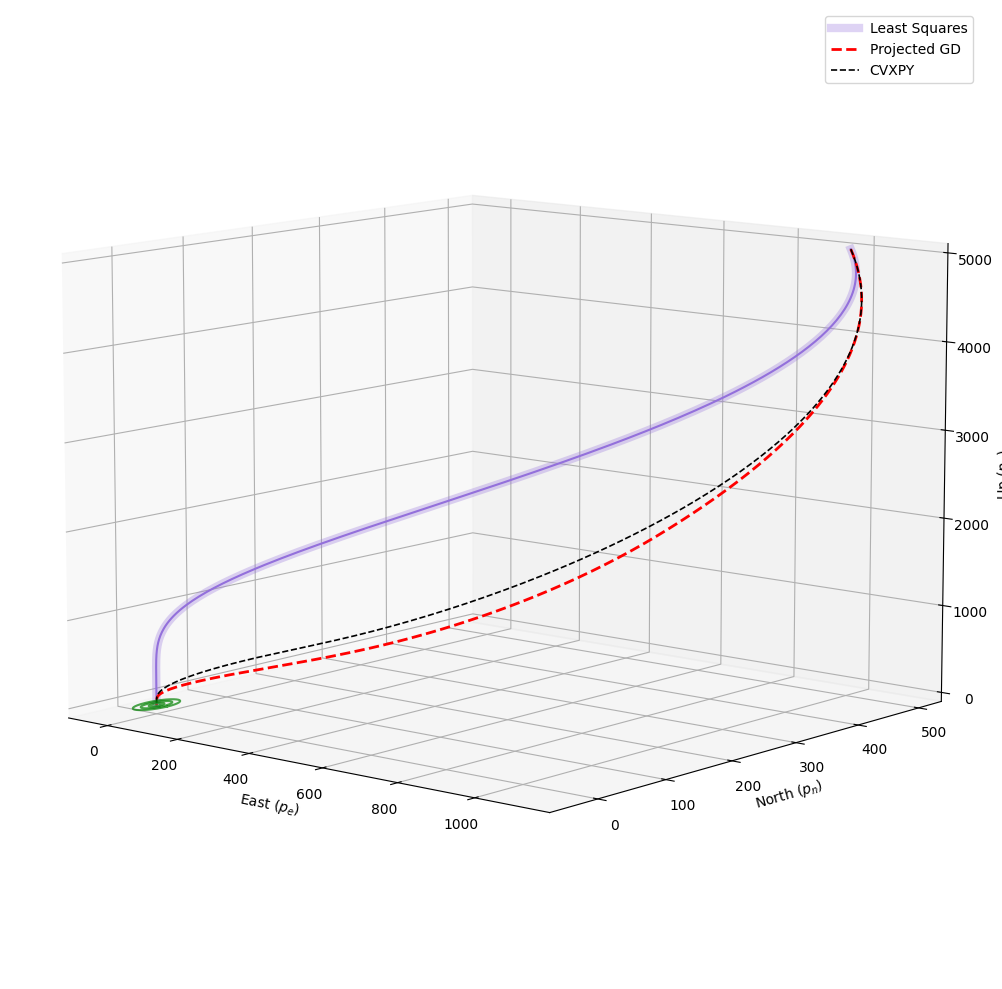

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=10, azim=-50, roll=0)

# ----- LS Trajectory -----
ax.plot(X_ls[0, :], X_ls[1, :], X_ls[2, :],
        color="mediumpurple", linewidth=6, alpha=0.3,
        label="Least Squares")
ax.plot(X_ls[0, :], X_ls[1, :], X_ls[2, :],
        color="mediumpurple", linewidth=1.5)

# ----- PGD Trajectory -----
ax.plot(X_pgd[0, :], X_pgd[1, :], X_pgd[2, :],
        "r--", linewidth=2.0, label="Projected GD")

# ------CVX Trajectory -----
ax.plot(X_opt[0, :], X_opt[1, :], X_opt[2, :], 'k--', linewidth=1.2, label="CVXPY")

# ----- Landing pad (circles) -----
theta = np.linspace(0, 2*np.pi, 200)
radii = [10, 20, 30]

for r in radii:
    pe_circle = x_des[0] + r * np.cos(theta)
    pn_circle = x_des[1] + r * np.sin(theta)
    pu_circle = np.zeros_like(theta) + x_des[2]
    ax.plot(pe_circle, pn_circle, pu_circle, "g", alpha=0.7)

# ----- Labels & view -----
ax.set_xlabel("East $(p_e)$")
ax.set_ylabel("North $(p_n)$")
ax.set_zlabel("Up $(p_u)$")
ax.legend()

plt.tight_layout()
plt.show()


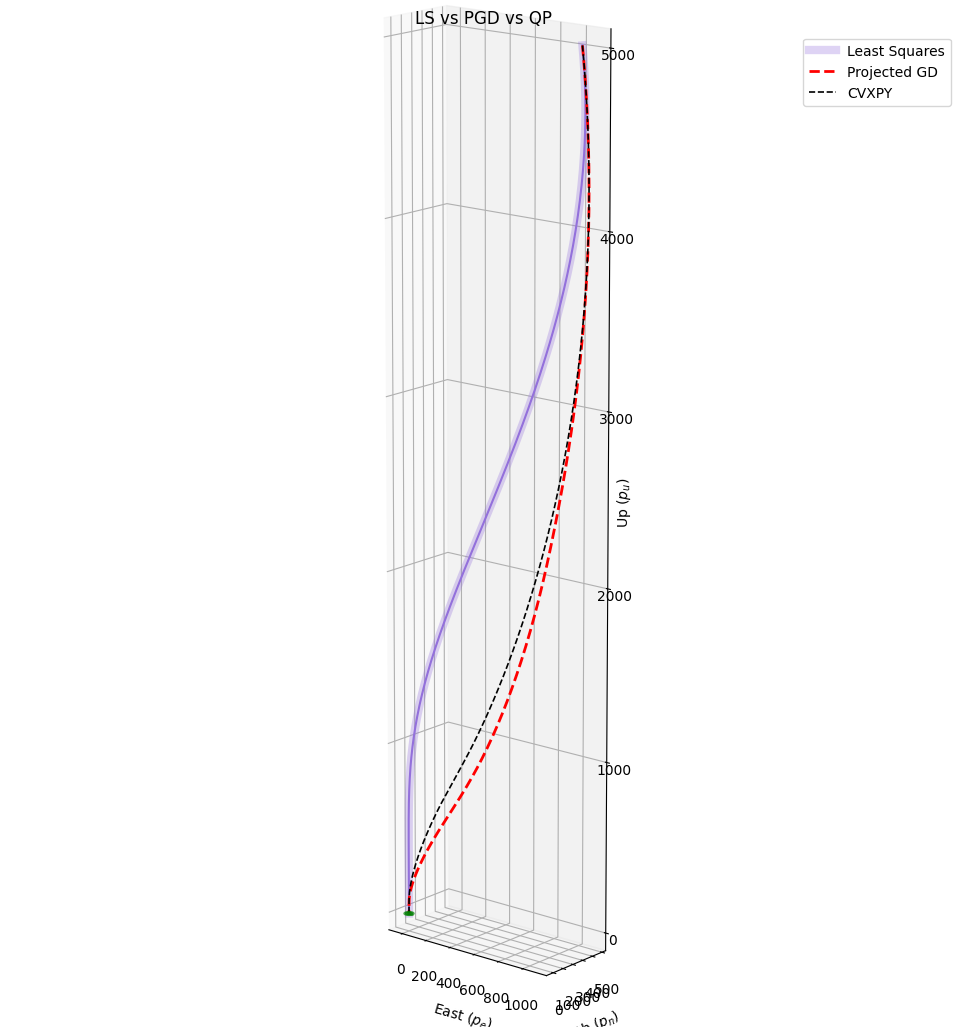

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=15, azim=-50, roll=0)

# =========================
# LS Trajectory
# =========================
ax.plot(X_ls[0,:], X_ls[1,:], X_ls[2,:],
        color="mediumpurple", linewidth=6, alpha=0.3,
        label="Least Squares")
ax.plot(X_ls[0,:], X_ls[1,:], X_ls[2,:],
        color="mediumpurple", linewidth=1.5)

# =========================
# PGD Trajectory
# =========================
ax.plot(X_pgd[0,:], X_pgd[1,:], X_pgd[2,:],
        "r--", linewidth=2.0, label="Projected GD")

# =========================
# OPT Trajectory (NEW)
# =========================
ax.plot(X_opt[0,:], X_opt[1,:], X_opt[2,:],
        'k--', linewidth=1.2,
        label="CVXPY")



# =========================
# Landing pad (circles)
# =========================
theta = np.linspace(0, 2*np.pi, 200)
radii = [10, 20, 30]

for r in radii:
    pe_circle = x_des[0] + r*np.cos(theta)
    pn_circle = x_des[1] + r*np.sin(theta)
    pu_circle = np.zeros_like(theta) + x_des[2]
    ax.plot(pe_circle, pn_circle, pu_circle,
            "g", alpha=0.7)


ax.set_xlabel("East $(p_e)$")
ax.set_ylabel("North $(p_n)$")
ax.set_zlabel("Up $(p_u)$")
ax.set_title("LS vs PGD vs QP")
ax.legend()

ax.set_box_aspect((
    np.ptp(X_opt[0,:]),
    np.ptp(X_opt[1,:]),
    np.ptp(X_opt[2,:])
))

plt.tight_layout()
plt.show()


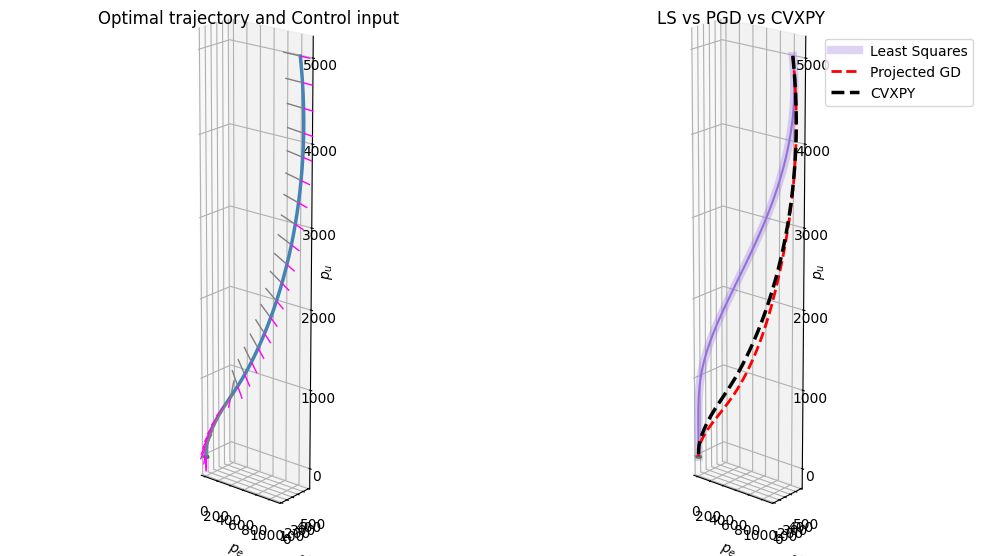

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(10,10), dpi=100)

axL = fig.add_subplot(1, 2, 1, projection='3d')
axR = fig.add_subplot(1, 2, 2, projection='3d')

for ax in (axL, axR):
    ax.view_init(elev=20, azim=-50, roll=0)
    ax.set_xlabel(r'$p_e$')
    ax.set_ylabel(r'$p_n$')
    ax.set_zlabel(r'$p_u$')


theta = np.linspace(0, 2*np.pi, 200)
radii = [10, 20, 30]
for ax in (axL, axR):
    for r in radii:
        pe_circle = x_des[0] + r*np.cos(theta)
        pn_circle = x_des[1] + r*np.sin(theta)
        pu_circle = np.zeros_like(theta) + x_des[2]
        ax.plot(pe_circle, pn_circle, pu_circle, "g", alpha=0.7)


axL.plot(*X_opt[:3,:], color="steelblue", linewidth=2.5)

_ = 10
N_ = X_opt.shape[1] - 1
for i in range(0, N_, 10):
    __ = np.linalg.norm(U_opt[:, i]) / 200
    __ = max(__, 1e-6)

    axL.quiver(X_opt[0,i], X_opt[1,i], X_opt[2,i],
               -U_opt[0,i]*_, -U_opt[1,i]*_, -U_opt[2,i]*_,
               color='magenta', linewidths=1, arrow_length_ratio=0)

    axL.quiver(X_opt[0,i], X_opt[1,i], X_opt[2,i],
               U_opt[0,i]/__, U_opt[1,i]/__, U_opt[2,i]/__,
               color='gray', linewidths=1, arrow_length_ratio=0)

axL.set_title("Optimal trajectory and Control input")

axR.plot(X_ls[0,:], X_ls[1,:], X_ls[2,:],
        color="mediumpurple", linewidth=6, alpha=0.3, label="Least Squares")
axR.plot(X_ls[0,:], X_ls[1,:], X_ls[2,:],
        color="mediumpurple", linewidth=1.5)

axR.plot(X_pgd[0,:], X_pgd[1,:], X_pgd[2,:],
        "r--", linewidth=2.0, label="Projected GD")

axR.plot(X_opt[0,:], X_opt[1,:], X_opt[2,:],
        'k--', linewidth=2.5, label="CVXPY")


axR.set_title("LS vs PGD vs CVXPY")
axR.legend()


P = np.hstack([X_ls[:3,:], X_pgd[:3,:], X_opt[:3,:]])
xmin, xmax = P[0].min(), P[0].max()
ymin, ymax = P[1].min(), P[1].max()
zmin, zmax = P[2].min(), P[2].max()


mx = 0.05 * (xmax - xmin + 1e-9)
my = 0.05 * (ymax - ymin + 1e-9)
mz = 0.05 * (zmax - zmin + 1e-9)

xlim = (xmin - mx, xmax + mx)
ylim = (ymin - my, ymax + my)
zlim = (zmin - mz, zmax + mz)

for ax in (axL, axR):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)

    ax.set_box_aspect((xlim[1]-xlim[0], ylim[1]-ylim[0], zlim[1]-zlim[0]))

plt.tight_layout()
plt.show()


In [ ]:
!pip -q install celluloid

from celluloid import Camera
from matplotlib import rc

def make_3d_anim(x1,u1,x2=[],u2=[],playback_speed=2):
  fig = plt.figure(figsize=(10,10), dpi=100)
  ax = fig.add_subplot(projection='3d')
  ax.view_init(elev=10, azim=-75, roll=0)
  _ = 10

  N_ = x1.shape[1]-1
  camera = Camera(fig)

  for i in range(0, N_, playback_speed):
    ax.plot(*x1[:3,:], alpha=0.2)
    if len(x2):
      ax.plot(*x2[:3,:], alpha=0.2)

    __ = np.linalg.norm(u1[:,i])/200
    __ = max(__, 1e-6)  # <-- safety patch

    ax.plot(x1[0,:i+1],x1[1,:i+1],x1[2,:i+1])
    ax.quiver(x1[0,i],x1[1,i],x1[2,i],-u1[0,i]*_,-u1[1,i]*_,-u1[2,i]*_,
              color='magenta', linewidths=2, arrow_length_ratio = 0)
    ax.quiver(x1[0,i],x1[1,i],x1[2,i],u1[0,i]/__,u1[1,i]/__,u1[2,i]/__,
              color='gray', linewidths=4, arrow_length_ratio = 0)

    if len(x2):
      __2 = np.linalg.norm(u2[:,i])/200
      __2 = max(__2, 1e-6)

      ax.plot(x2[0,:i+1],x2[1,:i+1],x2[2,:i+1])
      ax.quiver(x2[0,i],x2[1,i],x2[2,i],-u2[0,i]*_,-u2[1,i]*_,-u2[2,i]*_,
                color='red', linewidths=2, arrow_length_ratio = 0)
      ax.quiver(x2[0,i],x2[1,i],x2[2,i],u2[0,i]/__2,u2[1,i]/__2,u2[2,i]/__2,
                color='black', linewidths=4, arrow_length_ratio = 0)

    th = np.linspace(0,2*np.pi, 200)
    ax.plot(100*np.cos(th),100*np.sin(th),0,alpha=0.5,color='green')
    ax.plot(200*np.cos(th),200*np.sin(th),0,alpha=0.5,color='green')
    ax.set_xlabel(r'$p_e$')
    ax.set_ylabel(r'$p_n$')
    ax.set_zlabel(r'$p_u$')
    ax.axis('equal')

    camera.snap()

  plt.close()
  anim = camera.animate(blit=False, interval=100)
  rc('animation', html='jshtml')
  return anim

anim = make_3d_anim(X_opt, U_opt, playback_speed=2)
anim
